# Lecture 15: Intro to Pytorch

PyTorch is a popular deep learning framework.
It is very similar to Needle!
Today we'll do a brief tour of PyTorch.

**Acknowledgement**: parts of this notebook were adapted from the official PyTorch ["Intro"](https://docs.pytorch.org/tutorials/beginner/basics/intro.html) tutorial. 
Parts of this notebook was generated using generative AI (Google Gemini): specific cells will denote when AI collaboration was used.

In [ ]:
# first some imports/helper functions
import math
import time

from typing import Any

import torch
import torchvision
from torch.utils.data import DataLoader

from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import numpy as np


def count_model_parameters(model: torch.nn.Module) -> int:
    """Counts the number of trainable parameters in a model.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# torch.Tensor

Just like `needle.Tensor`, PyTorch also has its own Tensor class: `torch.Tensor`:

In [ ]:
import torch

# create a 1d tensor
x = torch.tensor([1, 2, 3], dtype=torch.float32)
print(f"x: {x}")

x: tensor([1., 2., 3.])


In [ ]:
# create a 2d tensor
W = torch.tensor([
    [1, 1, 1],
    [0, 1, 0],
    [0, 0, 2],
], dtype=torch.float32)

print(f"W: {W}")

W: tensor([[1., 1., 1.],
        [0., 1., 0.],
        [0., 0., 2.]])


In [ ]:
# matrix multiplication: @ operator
y = W @ x
print(f"y: {y}")

# the above works, but here let's be super precise about compatible matmult shapes:
y2 = W @ x.reshape(shape=(3, 1))
print(f"y2: {y2}")

y: tensor([6., 2., 6.])
y2: tensor([[6.],
        [2.],
        [6.]])


In [ ]:
# torch also has convenience methods: torch.ones, torch.zeros, torch.rand
my_ones = torch.ones(size=(3, 4), dtype=torch.float32)
print(f"my_ones: {my_ones}")

my_zeros = torch.zeros(size=(2, 1), dtype=torch.float32)
print(f"my_zeros: {my_zeros}")

# uniform random nums from [0, 1)
my_rand = torch.rand(size=(2, 2), dtype=torch.float32)
print(f"my_rand: {my_rand}")

my_ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
my_zeros: tensor([[0.],
        [0.]])
my_rand: tensor([[0.2019, 0.9419],
        [0.8975, 0.0601]])


## Regarding randomness

Tip: if you ever want to (try) to make your code deterministic and reproducible, you can set the random seed to "control" the randomness.

This is useful for, say, trying to ensure that your experiments are fully reproducible.

Tip: in practice, it's very hard to ensure that experiment runs are fully reproducible (tldr: computers are complicated).
Still, it's handy to know that random seeds exist.

To learn more: https://docs.pytorch.org/docs/stable/notes/randomness.html

In [ ]:
# without torch.manual_seed(), if I re-run this cell 3 times, I'll get 3 different
# values of the random tensor
print("rand (without torch.manual_seed)")
print(torch.rand(size=(2, 2), dtype=torch.float32))


rand (without torch.manual_seed)
tensor([[0.6026, 0.0657],
        [0.0219, 0.0136]])


In [ ]:
# WITH torch.manual_seed(), torch.rand() always returns the same vals!
print("rand (with torch.manual_seed(42))")
torch.manual_seed(42)
print(torch.rand(size=(2, 2), dtype=torch.float32))

rand (with torch.manual_seed(42))
tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])


# torch.nn.Module

Similar to `needle.Module`, pytorch also has a `torch.nn.Module` that functions very similarly!

All pytorch layers subclass the `torch.nn.Module` class.
Here are some common Layers that we've seen in the class:

- [torch.nn.Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)
- [torch.nn.ReLU](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
- [torch.nn.LayerNorm](https://docs.pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html)
- [torch.nn.BatchNorm1d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)
- [torch.nn.Sigmoid](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html)
- [torch.nn.Softmax](https://docs.pytorch.org/docs/stable/generated/torch.nn.Softmax.html)
- [torch.nn.Dropout](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
- [torch.nn.CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
- [torch.nn.BCELoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)
- [torch.nn.MSELoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)
- [torch.nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [torch.nn.BatchNorm2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)
- [torch.nn.AvgPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html)
- [torch.nn.MaxPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)

In [ ]:
# create a Linear layer
linear = torch.nn.Linear(in_features=2, out_features=4)
print(linear)
print(linear.weight)
print(linear.bias)

Linear(in_features=2, out_features=4, bias=True)
Parameter containing:
tensor([[ 0.1102,  0.5713],
        [ 0.0773, -0.2230],
        [ 0.1900, -0.1918],
        [ 0.2976,  0.6313]], requires_grad=True)
Parameter containing:
tensor([ 0.4087, -0.3091,  0.4082,  0.1265], requires_grad=True)


In [ ]:
# run the Linear forward pass
# x.shape=[B, 2]
x = torch.tensor([1, 2], dtype=torch.float32).reshape(shape=(1, 2))
y = linear(x)
print(f"x: {x}")
print(f"y: {y}")

x: tensor([[1., 2.]])
y: tensor([[ 1.6616, -0.6778,  0.2147,  1.6868]], grad_fn=<AddmmBackward0>)


In [ ]:
# construct a Linear->LayerNorm->Relu block
linear = torch.nn.Linear(in_features=2, out_features=4)
layer_norm = torch.nn.LayerNorm(normalized_shape=4)
relu = torch.nn.ReLU()

seq = torch.nn.Sequential(linear, layer_norm, relu)
print(seq)

# forward pass with sequential
y = seq(x)
print(f"y: {y}")

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
  (2): ReLU()
)
y: tensor([[0.0000, 0.0000, 1.3499, 0.3478]], grad_fn=<ReluBackward0>)


## pytorch documentation

Pytorch's documentation is often quite good.
For instance, here is the documentation for `torch.nn.LayerNorm`: https://docs.pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html

From the documentation, we see that `torch.nn.LayerNorm`'s affine scale/shift parameters are called `weight` and `bias`:

In [ ]:
print(layer_norm.weight)
print(layer_norm.bias)

Parameter containing:
tensor([1., 1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)


## Custom modules
In pytorch, a common practice is to define your model architectures by defining custom subclasses of the `torch.nn.Module`.

For instance, let's create a simple two-layer MLP using pytorch idioms:

x -> Linear -> LayerNorm -> Relu -> Linear -> logits.

In [ ]:
class MyMLPV1(torch.nn.Module):
    # V1: explicit layers
    def __init__(self, num_input_feats: int, num_classes: int, hidden_dim: int = 8):
        super().__init__()
        self.num_classes = num_classes
        self.linear1 = torch.nn.Linear(in_features=num_input_feats, out_features=hidden_dim)
        self.layer_norm1 = torch.nn.LayerNorm(normalized_shape=hidden_dim)
        self.relu1 = torch.nn.ReLU()
        self.linear2 = torch.nn.Linear(in_features=hidden_dim, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.linear1(x)
        out = self.layer_norm1(out)
        out = self.relu1(out)
        logits = self.linear2(out)
        return logits

In [ ]:
# I can instantiate my module
my_mlp_v1 = MyMLPV1(num_input_feats=2, num_classes=10)
print(my_mlp_v1)

MyMLPV1(
  (linear1): Linear(in_features=2, out_features=8, bias=True)
  (layer_norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (relu1): ReLU()
  (linear2): Linear(in_features=8, out_features=4, bias=True)
)


Let's inspect the weights of our model:

In [ ]:
# First linear layer's weight, bias parameters
print(f"linear1.weight.shape: {my_mlp_v1.linear1.weight.shape}")
print(my_mlp_v1.linear1.weight)

print(f"linear1.bias.shape: {my_mlp_v1.linear1.bias.shape}")
print(my_mlp_v1.linear1.bias)

## Module parameters

`torch.nn.Modules` know how to retrieve the trainable Parameters, and similar to Needle, pytorch will recursively search for Parameters of sub-modules!

The Optimizers will use the `torch.nn.Module::parameters()` method to easily fetch the Parameters.

In [ ]:
model_params = list(my_mlp_v1.parameters())
print(f"model_params: {model_params}")
print(f"total num model params: {sum([p.numel() for p in model_params])}")
# we also have a helper function that does this:
print(f"total num model params (helper fn): {count_model_parameters(my_mlp_v1)}")

model_params: [Parameter containing:
tensor([[ 0.0445, -0.4826],
        [ 0.2180, -0.2435],
        [ 0.2167, -0.1473],
        [ 0.5865, -0.4191],
        [-0.4217, -0.4217],
        [ 0.6360,  0.2356],
        [ 0.6804, -0.5836],
        [-0.7014, -0.5532]], requires_grad=True), Parameter containing:
tensor([-0.4757,  0.2864,  0.2532,  0.5876, -0.3652, -0.4820,  0.3752, -0.2858],
       requires_grad=True), Parameter containing:
tensor([1., 1., 1., 1., 1., 1., 1., 1.], requires_grad=True), Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True), Parameter containing:
tensor([[ 0.2146, -0.0839,  0.2022, -0.2747, -0.1784,  0.1078,  0.0747, -0.0901],
        [ 0.2107,  0.2403, -0.2564, -0.1888,  0.3237, -0.1193, -0.1253, -0.3421],
        [-0.2025,  0.0883, -0.0467, -0.2566,  0.0083, -0.2415, -0.3000, -0.1947],
        [-0.3094, -0.2251,  0.3534,  0.0668,  0.1090, -0.3298, -0.2322, -0.1177]],
       requires_grad=True), Parameter containing:
tensor([ 0.0553, 

## Composing Modules

Let's refactor our MyMLPV1 to generalize from a two-layer NN classifier to an N-layer NN classifier.
For this, we'll define a "LinearBlock" that consists of: `Linear -> LayerNorm -> Relu`.

Then, we'll define an `MyMLPV2` Module that creates N repeated `LinearBlock`'s, followed by a final `Linear -> logits -> CrossEntropyLoss`.

<img src=figures/mlp_linearblocks.png alt="An MLP, consisting of repeated LinearBlock's" width="90%">


In [ ]:
class LinearBlock(torch.nn.Module):
    # Linear -> LayerNorm -> Relu
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.linear = torch.nn.Linear(in_features=in_features, out_features=out_features)
        self.layer_norm = torch.nn.LayerNorm(normalized_shape=out_features)
        self.relu = torch.nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.linear(x)
        out = self.layer_norm(out)
        out = self.relu(out)
        return out

class MyMLPV2(torch.nn.Module):
    # V2: use the LinearBlock
    def __init__(self, num_input_feats: int, num_classes: int, num_blocks: int = 2, hidden_dim: int = 8):
        super().__init__()
        self.num_classes = num_classes
        self.num_blocks = num_blocks
        self.hidden_dim = hidden_dim
        # first linear is "special": num_input_feats -> hidden_dim
        linear1 = torch.nn.Linear(in_features=num_input_feats, out_features=hidden_dim)
        # remaining linear blocks operate on hidden_dim -> hidden_dim
        # Create LinearBlocks
        if False:
            # (impl1) using a for-loop
            modules = [linear1]
            for _ in range(self.num_blocks):
                modules.append(LinearBlock(in_features=hidden_dim, out_features=hidden_dim))
            self.linear_blocks = torch.nn.Sequential(*modules)
        else:
            # (impl2) using a list comprehension
            self.linear_blocks = torch.nn.Sequential(
                linear1,
                *[
                    LinearBlock(in_features=hidden_dim, out_features=hidden_dim)
                    for _ in range(self.num_blocks)
                ]
            )
        # final linear block produces logits
        self.linear_cls = torch.nn.Linear(in_features=hidden_dim, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.linear_blocks(x)
        logits = self.linear_cls(out)
        return logits

In [7]:
# Let's create a 2-layer NN
model_v2a = MyMLPV2(num_input_feats=2, num_classes=10, num_blocks=1)
print(model_v2a)
print("num model parameters:", count_model_parameters(model_v2a))

MyMLPV2(
  (linear_blocks): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): LinearBlock(
      (linear): Linear(in_features=8, out_features=8, bias=True)
      (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (relu): ReLU()
    )
  )
  (linear_cls): Linear(in_features=8, out_features=10, bias=True)
)
202


In [9]:
# Let's create a 5-layer NN!
model_v2b = MyMLPV2(num_input_feats=2, num_classes=10, num_blocks=5)
print(model_v2b)
print("num model parameters:", count_model_parameters(model_v2b))

MyMLPV2(
  (linear_blocks): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): LinearBlock(
      (linear): Linear(in_features=8, out_features=8, bias=True)
      (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (relu): ReLU()
    )
    (2): LinearBlock(
      (linear): Linear(in_features=8, out_features=8, bias=True)
      (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (relu): ReLU()
    )
    (3): LinearBlock(
      (linear): Linear(in_features=8, out_features=8, bias=True)
      (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (relu): ReLU()
    )
    (4): LinearBlock(
      (linear): Linear(in_features=8, out_features=8, bias=True)
      (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (relu): ReLU()
    )
    (5): LinearBlock(
      (linear): Linear(in_features=8, out_features=8, bias=True)
      (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)

In [12]:
# For fun, we can iterate through the layers of our NN and print each layer + params!

# Approach 1: via `torch.nn.Module::named_parameters()`
for name, param in model_v2b.named_parameters():
    print(f"name: {name} (shape={param.shape})")
    print("param:", param)

name: linear_blocks.0.weight (shape=torch.Size([8, 2]))
param: Parameter containing:
tensor([[ 0.2667,  0.3954],
        [ 0.7024,  0.1794],
        [-0.0644,  0.0492],
        [-0.5218,  0.3030],
        [-0.5535, -0.2575],
        [ 0.3087, -0.6107],
        [ 0.2294, -0.5015],
        [-0.0896, -0.5953]], requires_grad=True)
name: linear_blocks.0.bias (shape=torch.Size([8]))
param: Parameter containing:
tensor([-0.6274, -0.1805,  0.2317,  0.0066,  0.0435,  0.5860,  0.6072,  0.5206],
       requires_grad=True)
name: linear_blocks.1.linear.weight (shape=torch.Size([8, 8]))
param: Parameter containing:
tensor([[-0.1094,  0.2891, -0.3477,  0.3382,  0.1822, -0.1577,  0.2397,  0.2827],
        [-0.2166,  0.2857, -0.0846, -0.0490,  0.0955, -0.2381, -0.2377,  0.3437],
        [-0.2016, -0.1670, -0.0101,  0.2546,  0.0562, -0.1935,  0.1418, -0.1294],
        [-0.1510, -0.1877,  0.0028,  0.0521,  0.0681,  0.2309,  0.3112, -0.0422],
        [-0.0658,  0.3221, -0.1189, -0.1934, -0.3331,  0.0234,

In [14]:
# Approach 2: via directly accessing layer parameters
for layer_idx, layer in enumerate(model_v2b.linear_blocks):
    print(f"{layer_idx} layer: {layer}")
    if isinstance(layer, torch.nn.Linear):
        print(f"weight (shape={layer.weight.shape}): {layer.weight}")
        print(f"bias (shape={layer.bias.shape}): {layer.bias}")
print(f"linear_cls: {model_v2b.linear_cls}")
print(f"linear_cls.weight (shape={model_v2b.linear_cls.weight.shape}): {model_v2b.linear_cls.weight}")
print(f"linear_cls.bias (shape={model_v2b.linear_cls.bias.shape}): {model_v2b.linear_cls.bias}")

0 layer: Linear(in_features=2, out_features=8, bias=True)
weight (shape=torch.Size([8, 2])): Parameter containing:
tensor([[ 0.2667,  0.3954],
        [ 0.7024,  0.1794],
        [-0.0644,  0.0492],
        [-0.5218,  0.3030],
        [-0.5535, -0.2575],
        [ 0.3087, -0.6107],
        [ 0.2294, -0.5015],
        [-0.0896, -0.5953]], requires_grad=True)
bias (shape=torch.Size([8])): Parameter containing:
tensor([-0.6274, -0.1805,  0.2317,  0.0066,  0.0435,  0.5860,  0.6072,  0.5206],
       requires_grad=True)
1 layer: LinearBlock(
  (linear): Linear(in_features=8, out_features=8, bias=True)
  (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (relu): ReLU()
)
2 layer: LinearBlock(
  (linear): Linear(in_features=8, out_features=8, bias=True)
  (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (relu): ReLU()
)
3 layer: LinearBlock(
  (linear): Linear(in_features=8, out_features=8, bias=True)
  (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_af

# Optimizers

PyTorch provides implementations of common optimizers such as:

- [torch.optim.SGD](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)
    - This supports Momentum
- [torch.optim.Adam](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

Both of the above support L2 regularization, via the `weight_decay` parameter (aka lambda, controlling the strength of L2 regularization).

Creating them is simple: when we instantiate the optimizer, we tell it which model parameters it should optimize:

In [16]:
model_v2b = MyMLPV2(num_input_feats=2, num_classes=10, num_blocks=5)
# SGD with momentum and L2 regularization (weight_decay)
optim_sgd = torch.optim.SGD(model_v2b.parameters(), lr=1e-3, weight_decay=0.01)

print(optim_sgd)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0.01
)


Later in this notebook we'll see how to actually use optimizers to train a model on a labeled training dataset, but here's a mock example:

In [26]:
torch.random.manual_seed(42)
model_v2b = MyMLPV2(num_input_feats=2, num_classes=10, num_blocks=2)
# SGD with momentum and L2 regularization (weight_decay)
optimizer = torch.optim.SGD(model_v2b.parameters(), lr=1e-3, weight_decay=0.01)

# create fake inputs and targets
# input.shape=[batchsize=4, d=2]
input = torch.rand(size=(4, 2), dtype=torch.float32)
# target.shape=[batchsize=4]. fake classification labels
target = torch.randint(low=0, high=10, size=(4,), dtype=torch.long)

loss_fn = torch.nn.CrossEntropyLoss()

# First: zero out gradients (ie from previous train iteration)
optimizer.zero_grad()
# Next: calculate loss for this batch, then perform backprop (ie calculate
#   adjoints!)
pred_logits = model_v2b(input)
loss_val = loss_fn(pred_logits, target)
print(f"input: {input}")
print(f"pred_logits: {pred_logits}")
print(f"target: {target}")
print(f"loss_val: {loss_val}")
loss_val.backward()
# Finally: ask the optimizer to update the model parameters using the
#   adjoints calculated by backprop (`loss_val.backward()`)
optimizer.step()

input: tensor([[0.7513, 0.7269],
        [0.8572, 0.1165],
        [0.8596, 0.2636],
        [0.6855, 0.9696]])
pred_logits: tensor([[-9.8525e-02,  1.9708e-01, -2.9350e-01, -3.3247e-04, -6.5159e-01,
         -4.3355e-01, -5.9839e-01, -8.7788e-01, -2.5644e-01, -4.1568e-01],
        [-2.0253e-01,  2.7154e-01, -2.4936e-01,  4.7886e-02, -6.2434e-01,
         -3.4791e-01, -5.9533e-01, -7.3552e-01, -1.8895e-01, -4.9332e-01],
        [-1.7995e-01,  2.5591e-01, -2.5937e-01,  3.7987e-02, -6.3181e-01,
         -3.7013e-01, -5.9798e-01, -7.7236e-01, -2.0520e-01, -4.7864e-01],
        [-8.4625e-02,  1.7971e-01, -2.9792e-01,  1.9639e-03, -6.7048e-01,
         -4.4175e-01, -6.0198e-01, -8.9929e-01, -2.6811e-01, -4.0060e-01]],
       grad_fn=<AddmmBackward0>)
target: tensor([3, 7, 0, 8])
loss_val: 2.3145923614501953


Let's take a closer look to show that `optimizer.step()` is indeed causing our model weights to change!

In [37]:
torch.random.manual_seed(42)
model_v2b = MyMLPV2(num_input_feats=2, num_classes=10, num_blocks=2)
# SGD with momentum and L2 regularization (weight_decay)
optimizer = torch.optim.SGD(model_v2b.parameters(), lr=1e-1)

# create fake inputs and targets
# input.shape=[batchsize=4, d=2]
input = torch.rand(size=(4, 2), dtype=torch.float32)
# target.shape=[batchsize=4]. fake classification labels
target = torch.randint(low=0, high=10, size=(4,), dtype=torch.long)

loss_fn = torch.nn.CrossEntropyLoss()

# Grab a copy of the original weights of the final linear_cls layer
linear_cls_w_pre_step = model_v2b.linear_cls.weight.clone()

# First: zero out gradients (ie from previous train iteration)
optimizer.zero_grad()
# Next: calculate loss for this batch, then perform backprop (ie calculate
#   adjoints!)
pred_logits = model_v2b(input)
loss_val = loss_fn(pred_logits, target)
loss_val.backward()
# Finally: ask the optimizer to update the model parameters using the
#   adjoints calculated by backprop (`loss_val.backward()`)
optimizer.step()

print(f"Before optimizer.step: {linear_cls_w_pre_step}")
print(f"After optimizer.step: {model_v2b.linear_cls.weight}")

Before optimizer.step: tensor([[ 0.0788, -0.1956, -0.1789, -0.0169,  0.1974, -0.0903, -0.2017, -0.1211],
        [-0.2641,  0.1261,  0.2737, -0.3328,  0.0821,  0.1826,  0.0641, -0.1259],
        [ 0.1845,  0.1858,  0.1322, -0.0621, -0.0936,  0.0378, -0.0625, -0.1054],
        [ 0.2260,  0.3038, -0.0350, -0.0792,  0.0052, -0.0211,  0.0850,  0.0991],
        [-0.3211, -0.1305,  0.2977,  0.1377, -0.0176, -0.2132, -0.2163, -0.3167],
        [-0.1152,  0.1194,  0.2254,  0.1632, -0.3125, -0.2126, -0.0558,  0.3420],
        [ 0.0511, -0.0916,  0.1463, -0.1347, -0.2288,  0.2581, -0.1608, -0.0709],
        [-0.3517,  0.2366,  0.2679,  0.1289, -0.2465, -0.3489, -0.2871,  0.2636],
        [ 0.1697,  0.2975,  0.1852,  0.0895, -0.0035, -0.2689, -0.3029, -0.3307],
        [ 0.1447, -0.1736, -0.0712, -0.2035, -0.0644, -0.2488, -0.2310,  0.1173]],
       grad_fn=<CloneBackward0>)
After optimizer.step: Parameter containing:
tensor([[ 0.0817, -0.1908, -0.1789, -0.0169,  0.2127, -0.0903, -0.1882, -0.1124

In [ ]:
# We can even take a look at the adjoints!
# Tip: linear_cls.weight.grad is d(loss)/d(linear_cls.weight)
print(f"linear_cls.weight.grad (shape={model_v2b.linear_cls.weight.grad.shape})")
print(model_v2b.linear_cls.weight.grad)

# let's manually apply the gradient ourself!
w_manual = linear_cls_w_pre_step + -1e-1 * model_v2b.linear_cls.weight.grad
print(w_manual)
print(f"L2 err between w_manual and optimizer.step: {torch.linalg.norm(w_manual.flatten() - model_v2b.linear_cls.weight.flatten())}")

linear_cls.weight.grad (shape=torch.Size([10, 8]))
tensor([[-0.0287, -0.0481,  0.0000,  0.0000, -0.1525,  0.0000, -0.1357, -0.0866],
        [ 0.0556,  0.0263,  0.0000,  0.0000,  0.2090,  0.0000,  0.1616,  0.1168],
        [ 0.0338,  0.0157,  0.0000,  0.0000,  0.1267,  0.0000,  0.0979,  0.0708],
        [-0.0535,  0.0126,  0.0000,  0.0000, -0.1606,  0.0000, -0.1065, -0.0849],
        [ 0.0234,  0.0108,  0.0000,  0.0000,  0.0876,  0.0000,  0.0676,  0.0490],
        [ 0.0297,  0.0141,  0.0000,  0.0000,  0.1119,  0.0000,  0.0866,  0.0626],
        [ 0.0246,  0.0111,  0.0000,  0.0000,  0.0919,  0.0000,  0.0708,  0.0513],
        [-0.0393, -0.0715,  0.0000,  0.0000, -0.2146,  0.0000, -0.1905, -0.1248],
        [-0.0745,  0.0166,  0.0000,  0.0000, -0.2069,  0.0000, -0.1343, -0.1141],
        [ 0.0289,  0.0125,  0.0000,  0.0000,  0.1073,  0.0000,  0.0824,  0.0599]])
tensor([[ 0.0817, -0.1908, -0.1789, -0.0169,  0.2127, -0.0903, -0.1882, -0.1124],
        [-0.2697,  0.1235,  0.2737, -0.3328,  

# Dataloaders

Pytorch also defines a Dataset, Dataloader abstraction to make it easy to ingest custom datasets into your projects.

For now, we'll use some convenience datasets and dataloaders pre-packaged into `torchvision`, a popular convenience library commonly used with `pytorch`.



In [43]:
# Download training data
training_data_cifar10 = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)

# Download test data from open datasets.
test_data_cifar10 = torchvision.datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)

batch_size_cifar10 = 64

# Create data loaders.
train_dataloader_cifar10 = DataLoader(training_data_cifar10, batch_size=batch_size_cifar10)
test_dataloader_cifar10 = DataLoader(test_data_cifar10, batch_size=batch_size_cifar10)

num_classes_cifar10 = 10
image_shape_cifar10 = (3, 32, 32)
for X, y in test_dataloader_cifar10:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


Let's visualize some examples from the test dataset!
We'll use the [matplotlib](https://matplotlib.org/) library, a popular third-party Python library for generating plots.

CIFAR10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


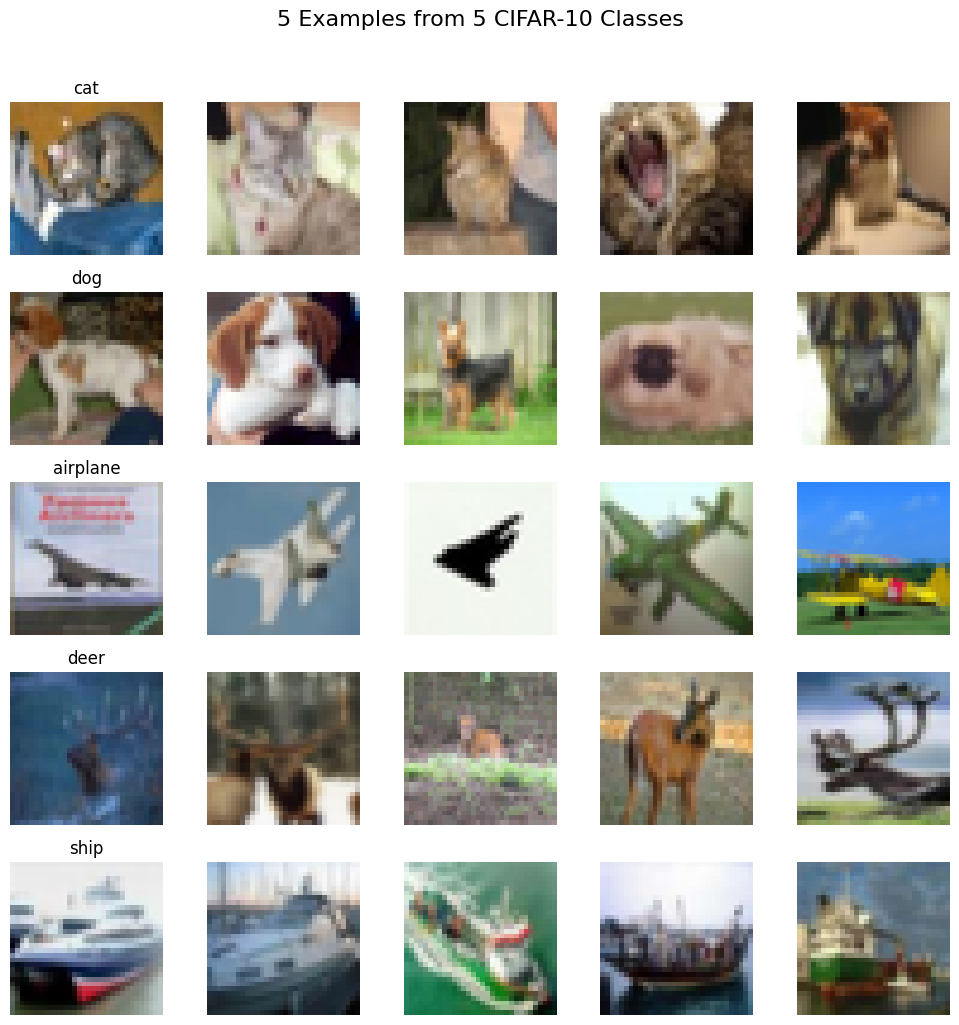

In [ ]:
# (Acknowledgement) Gemini was used to generate this cell, via the Colab+Gemini integration product
# feature. Unfortunately the exact prompt is lost, but from memory it roughly was:
# "Using matplotlib, generate a visualization of the CIFAR10 dataset, where we show 5 examples from 5 different classes in a 5x5 grid."

# Get class names from CIFAR10 dataset
class_names = test_data_cifar10.classes
print(f"CIFAR10 classes: {class_names}")

# Select 5 classes to visualize
selected_class_names = ["cat", "dog", "airplane", "deer", "ship"]
selected_classes_indices = [test_data_cifar10.classes.index(name) for name in selected_class_names]

# Prepare to store images for plotting
images_to_plot = []

# Collect 5 images for each selected class
for class_idx in selected_classes_indices:
    class_images = []
    for img, label in test_data_cifar10:
        if label == class_idx:
            # Convert from (C, H, W) to (H, W, C) and to numpy
            class_images.append(img.permute(1, 2, 0).numpy())
            if len(class_images) == 5:
                break
    images_to_plot.append(class_images)

# Create a 5x5 grid for plotting
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i, class_images in enumerate(images_to_plot):
    for j, img in enumerate(class_images):
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(selected_class_names[i])

plt.suptitle('5 Examples from 5 CIFAR-10 Classes', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Train loop
We now have all of the ingredients required to implement a simple pytorch train loop!

In [ ]:
# Train loop
def train_epoch(dataloader: DataLoader, model: torch.nn.Module, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, log_every_n_steps: int = 100):
    size = len(dataloader.dataset)
    model.train()
    tic_total = time.time()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction error
        # [B, C, H, W] -> [B, C*H*W]
        X = X.flatten(start_dim=1)

        # (1) Forward pass
        pred_logits = model(X)
        # (2) Calculate loss
        loss = loss_fn(pred_logits, y)

        # (3) Backpropagation
        loss.backward()

        # (4) Update model parameters
        optimizer.step()

        # important implementation detail: zero out all Parameter.grad's.
        # otherwise, gradients will continue accumulating across each batch.
        optimizer.zero_grad()

        if batch % log_every_n_steps == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    dur_total = time.time() - tic_total
    tput_total = size / dur_total
    print(f"Epoch training time: {dur_total} secs (throughput={tput_total} samples/sec)")

(optional) Aside: traditionally, the recommended order in the training loop was: `zero_grad() -> backward() -> step()`.

But, as of 2026, starting in pytorch2.0 the [advice is changed](https://discuss.pytorch.org/t/order-of-backward-step-and-zero-grad/119023/9): now they recommend `backward() -> step() -> zero_grad()` to slightly improve performance (mainly be reducing memory operations).

Big picture, not a huge deal.
But, interesting!
In this notebook, I'll follow the newer advice.

# Test loop

In addition to a train loop, let's also add a test loop that calculates the offline evaluation metrics we care about.
In this case: classification accuracy:

In [ ]:
# Evaluation
def test(dataloader: DataLoader, model: torch.nn.Module, loss_fn: torch.nn.Module):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    tic_total = time.time()
    with torch.no_grad():
        for X, y in dataloader:
            # [B, C, H, W] -> [B, C*H*W]
            X = X.flatten(start_dim=1)
            pred_logits = model(X)
            test_loss += loss_fn(pred_logits, y).item()
            # predicted class: class with largest probability (argmax)
            # compare against ground truth labels `y`
            # count number of matches (aka 0/1 classification loss)
            correct += (pred_logits.argmax(dim=1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    avg_accuracy = correct / size
    print(f"Test Error: \n Avg Accuracy: {(100*avg_accuracy):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    dur_total = time.time() - tic_total
    tput_total = size / dur_total
    print(f"Total test time: {dur_total} secs (throughput={tput_total} samples/sec)")

Now, let's train a simple classifier on CIFAR10!

In [ ]:
# Download training data
training_data_cifar10 = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)

# Download test data from open datasets.
test_data_cifar10 = torchvision.datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)

batch_size_cifar10 = 64

# Create data loaders.
train_dataloader_cifar10 = DataLoader(training_data_cifar10, batch_size=batch_size_cifar10)
test_dataloader_cifar10 = DataLoader(test_data_cifar10, batch_size=batch_size_cifar10)

# Create model
model = MyMLPV2(num_input_feats=3*32*32, num_classes=10, num_blocks=2)
print(model)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Run training
tic_start = time.time()
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_epoch(train_dataloader_cifar10, model, loss_fn, optimizer)
    test(test_dataloader_cifar10, model, loss_fn)
print(f"Done! Total train time: {time.time() - tic_start} secs")

MyMLPV2(
  (linear_blocks): Sequential(
    (0): Linear(in_features=3072, out_features=8, bias=True)
    (1): LinearBlock(
      (linear): Linear(in_features=8, out_features=8, bias=True)
      (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (relu): ReLU()
    )
    (2): LinearBlock(
      (linear): Linear(in_features=8, out_features=8, bias=True)
      (layer_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (relu): ReLU()
    )
  )
  (linear_cls): Linear(in_features=8, out_features=10, bias=True)
)
Epoch 1
-------------------------------
loss: 2.443614  [   64/50000]
loss: 2.349029  [ 6464/50000]
loss: 2.320590  [12864/50000]
loss: 2.296036  [19264/50000]
loss: 2.315725  [25664/50000]
loss: 2.305003  [32064/50000]
loss: 2.261751  [38464/50000]
loss: 2.313526  [44864/50000]
Total training time: 9.320467948913574 secs (throughput=5364.537518293614 samples/sec)
Test Error: 
 Accuracy: 14.0%, Avg loss: 2.268643 

Total test time: 1.6037728786468506 

# Visualizing predictions
For fun, let's visualize our model classifications!
Like in previous homeworks, we'll show the top5 most confident true positives ("easy examples"), and the top5 least confident false negatives ("hard examples").

In [ ]:
def plot_image_gallery(images: list[np.ndarray], titles: list[str], n_row: int = 3, n_col: int = 4) -> Figure:
    """Plots images+titles to figure.

    Args:
        images (list[np.ndarray]): shape=[num_images, img_height, img_width], or
            [num_images, img_height, img_width, 3]
        titles (list[str]): len=num_images.
        n_row (int, optional): Number of rows in figure. Defaults to 3.
        n_col (int, optional): Number of cols in figure. Defaults to 4.

    Returns:
        Figure: fig_out.
    """
    # inspired by:
    #   https://scikit-learn.org/stable/auto_examples/applications/plot_face_recognition.html
    # Helper function to plot a gallery of portraits
    if len(images) != len(titles):
        raise RuntimeError(f"num images must match num text titles: {len(images)} vs {len(titles)}")
    fig = plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    fig.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
    for i in range(n_row * n_col):
        axes_subplot = fig.add_subplot(n_row, n_col, i + 1)

        axes_subplot.imshow(images[i], cmap=plt.cm.gray)
        axes_subplot.set_title(titles[i], size=12)
        axes_subplot.set_xticks(())
        axes_subplot.set_yticks(())
    return fig


def visualize_predictions(pred_logits: np.ndarray, X: np.ndarray, num_chans_img: int, h_img: int, w_img: int, y: np.ndarray, ind_class_to_viz: int, class_name_to_viz: str, top_k: int = 5):
    """Visualizes the predictions of an image classifier.

    Args:
        pred_logits (np.ndarray): Model predictions. shape=[num_samples, num_classes].
        X (np.ndaray): Test images. shape=[num_samples, num_pixels], arranged row-by-row,
            in [C, H, W] -> [C*H*W] order.
        num_chans_img: Number of image channels. Should be 1, these are grayscale images.
        h_img: Image height, in pixels.
        w_img: Image width, in pixels.
        y (np.ndarray): Test labels. shape=[num_samples].
        ind_class_to_viz: Which ground-truth class to visualize predictions for.
        top_k: How many examples to visualize.

    Returns:
        fig: matplotlib Figure instance.
    """
    # shape=[num_samples, num_classes]
    pred_probs = _softmax_normalize(pred_logits)
    pred_labels = pred_probs.argmax(axis=1)
    mask_correct_preds = pred_labels == y

    # Visualize top k most confident true positives
    tp_indices = (mask_correct_preds == 1) & (y == ind_class_to_viz)
    tp_probs = pred_probs[tp_indices, ind_class_to_viz]

    sorted_inds = np.argsort(tp_probs)[::-1]
    sorted_inds_top_k = sorted_inds[:top_k]
    top_tp_probs = tp_probs[sorted_inds_top_k]

    Xtp = X[tp_indices, :]
    Xviz = Xtp[sorted_inds_top_k, :]

    yviz = y[tp_indices][sorted_inds_top_k]

    if num_chans_img > 1:
        # permute [b, c, h, w] -> [b, h, w, c] for matplotlib imshow()
        images = Xviz.reshape([Xviz.shape[0], num_chans_img, h_img, w_img]).transpose([0, 2, 3, 1])
    else:
        images = Xviz.reshape([Xviz.shape[0], h_img, w_img])

    if images.shape[0] < top_k:
        # skip, not enough true positives to visualize
        print(f"uhoh, not enough, skipping: {images.shape}, {sum(tp_indices)}")
        fig_tp = None
    else:
        titles = [f"p={top_tp_probs[i]:.3f} y_gt={yviz[i]}" for i in range(len(top_tp_probs))]

        fig_tp = plot_image_gallery(images, titles, n_row=1, n_col=5)
        fig_tp.suptitle(f"Top {top_k} most confident true positives (ind_class={ind_class_to_viz} {class_name_to_viz})")

    # Visualize top k least confident false negatives ("hard" examples)
    # Sort false negatives by their predicted prob for `digit`.
    # Take top k lowest scores, and visualize them.
    fn_indices = (mask_correct_preds == 0) & (y == ind_class_to_viz)

    fn_probs = pred_probs[fn_indices, ind_class_to_viz]

    sorted_inds_top_k = np.argsort(fn_probs)[:top_k]
    top_fn_probs = fn_probs[sorted_inds_top_k]

    # what did we predict?
    pred_label_fn = pred_labels[fn_indices][sorted_inds_top_k]
    pred_prob_fn = pred_probs[fn_indices, :][sorted_inds_top_k, pred_label_fn]

    Xviz = X[fn_indices, :][sorted_inds_top_k, :]
    yviz = y[fn_indices][sorted_inds_top_k]

    if num_chans_img > 1:
        # permute [b, c, h, w] -> [b, h, w, c] for matplotlib imshow()
        images = Xviz.reshape([Xviz.shape[0], num_chans_img, h_img, w_img]).transpose([0, 2, 3, 1])
    else:
        images = Xviz.reshape([Xviz.shape[0], h_img, w_img])

    if images.shape[0] < top_k:
        # skip, not enough true positives to visualize
        print(f"uhoh, not enough, skipping: {images.shape}, {sum(tp_indices)}")
        fig_fn = None
    else:
        titles = [f"\np_gt={top_fn_probs[i]:.3f} y_gt={yviz[i]}\npred={pred_label_fn[i]} ({pred_prob_fn[i]:.3f})" for i in range(len(top_fn_probs))]

        fig_fn = plot_image_gallery(images, titles, n_row=1, n_col=5)
        fig_fn.suptitle(f"Top {top_k} least confident false negatives (ind_class={ind_class_to_viz} {class_name_to_viz})\n")

        # make room for suptitle
        fig_fn.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.8, hspace=0.35)
    return fig_tp, fig_fn


def _softmax_normalize(vals: np.ndarray) -> np.ndarray:
    """Perform softmax normalization of input vals. The normalization
    is done across the last dimension.
    Args:
        vals: shape=[d0, d1, ..., dim].
    Returns:
        vals_norm: shape=[d0, d1, ..., dim].
    """
    vals_exp = np.exp(vals)
    norm_factor = np.sum(vals_exp, axis=-1)
    # note: need `norm_factor[:, np.newaxis]` to broadcast the division
    #   across the axis=1 of vals_exp
    #   otherwise, this line produces an error, due to numpy not knowing
    #   how to divide an array with shape=[batchsize, k] with an array with
    #   shape=[k].
    #     vals_exp / norm_factor
    return vals_exp / (norm_factor[:, np.newaxis])



In [ ]:
# Gather predictions
pred_logits = torch.zeros(size=(len(test_data_cifar10), num_classes_cifar10))
gt_labels = torch.zeros(size=(len(test_data_cifar10),), dtype=torch.long)
test_images = torch.zeros(size=(len(test_data_cifar10), 3*32*32), dtype=torch.float32)
with torch.no_grad():
    i1 = 0
    for X, y in test_dataloader_cifar10:
        i2 = i1 + X.shape[0]
        # [B, C, H, W] -> [B, C*H*W]
        X = X.flatten(start_dim=1)
        pred = model(X)
        pred_logits[i1:i2, :] = pred
        gt_labels[i1:i2] = y
        test_images[i1:i2, :] = X
        i1 = i2

uhoh, not enough, skipping: (0, 32, 32, 3), 0


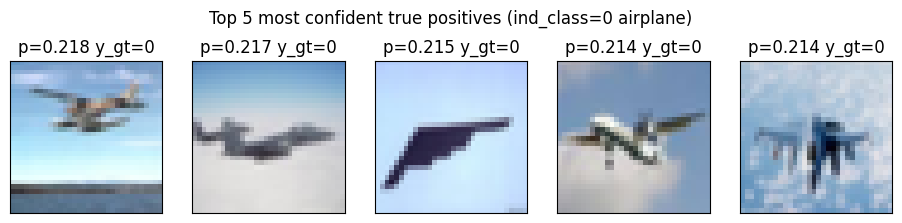

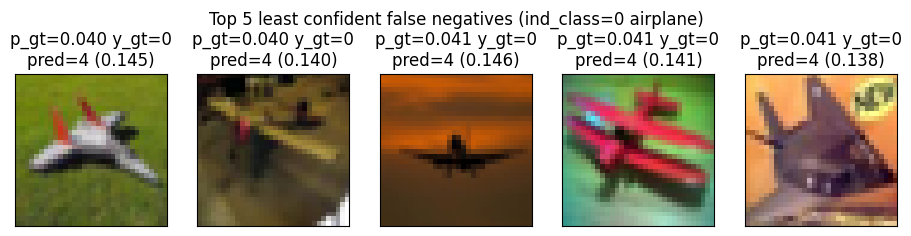

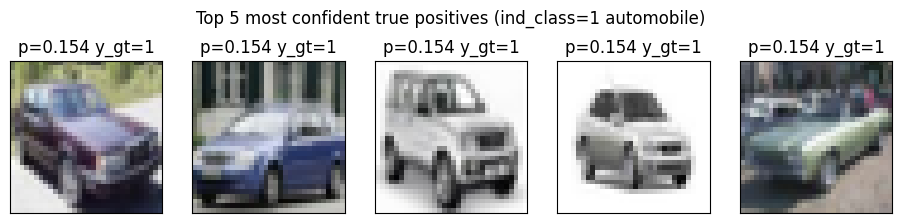

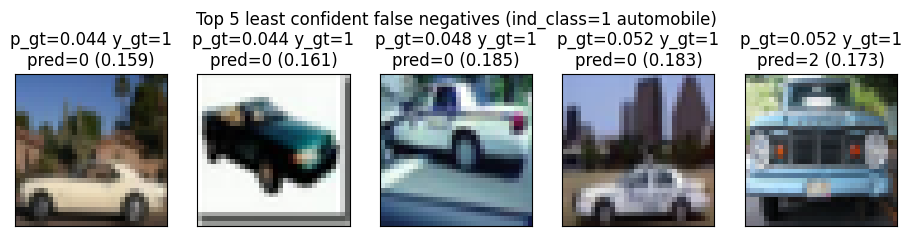

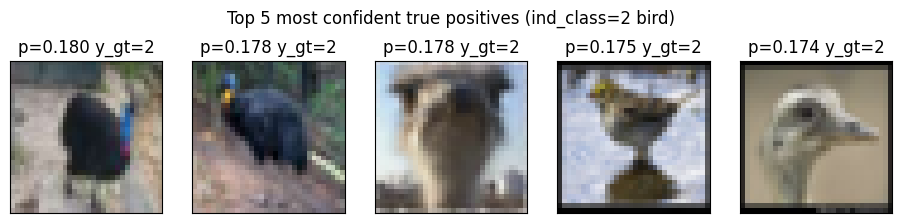

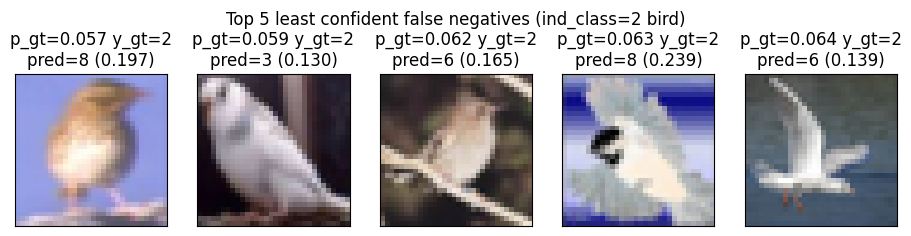

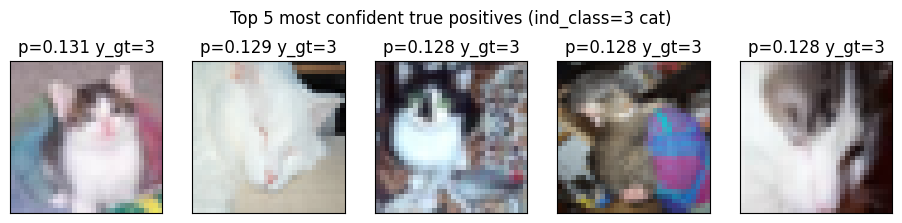

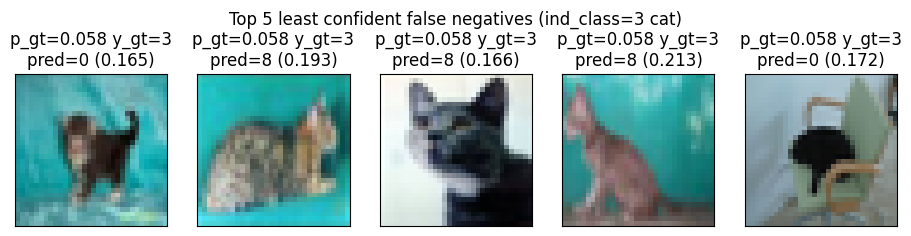

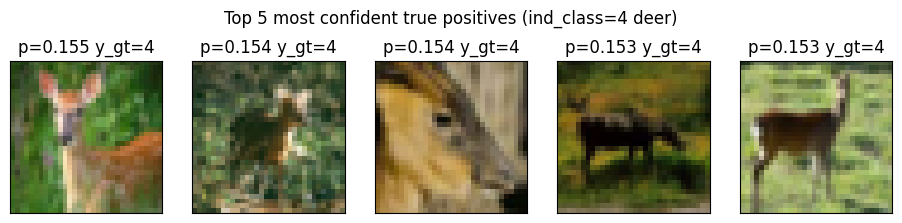

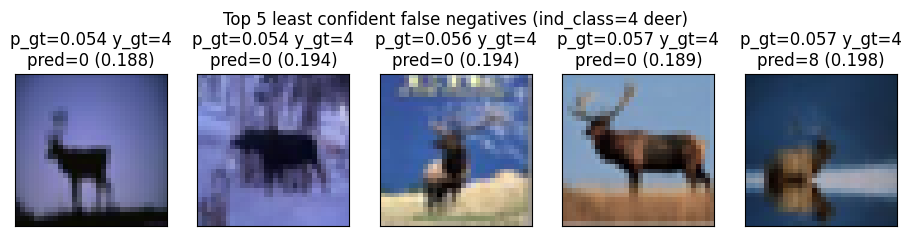

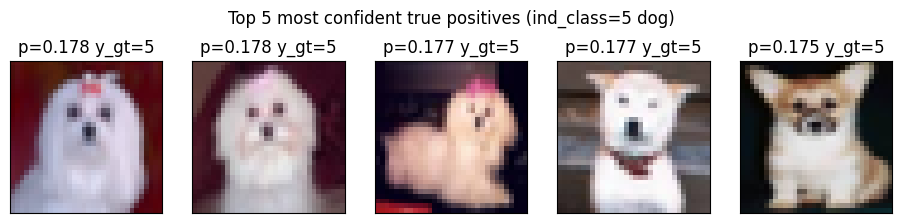

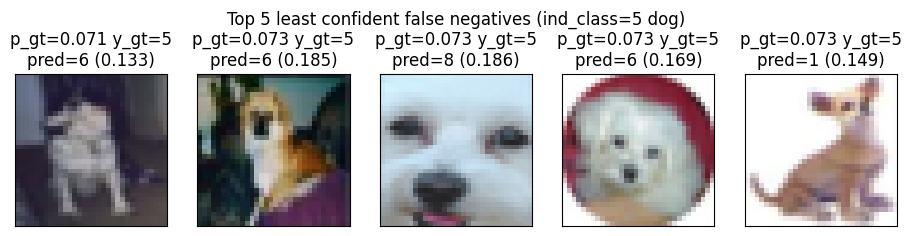

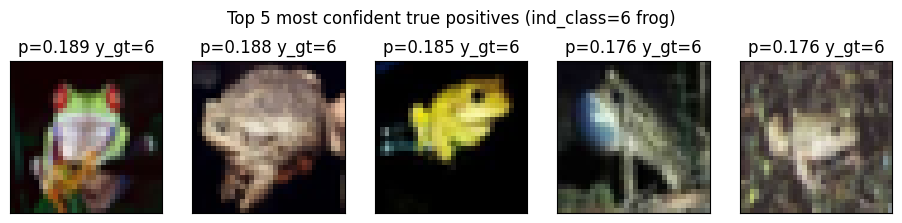

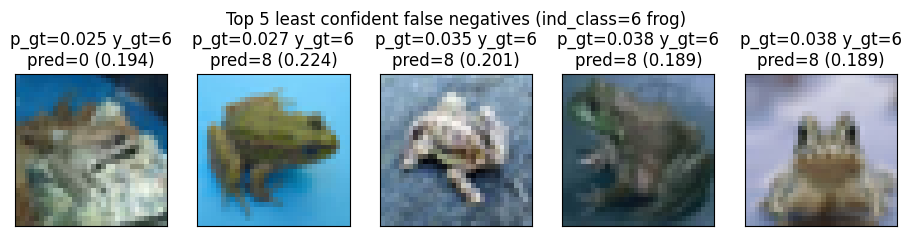

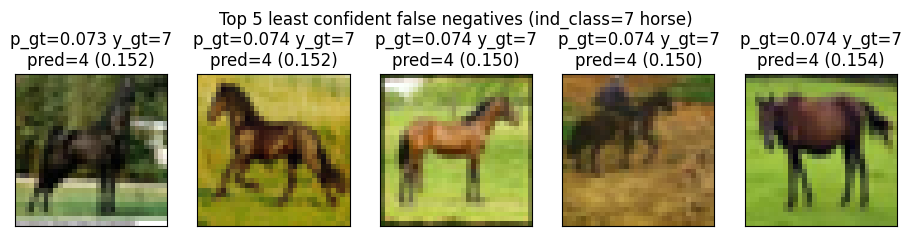

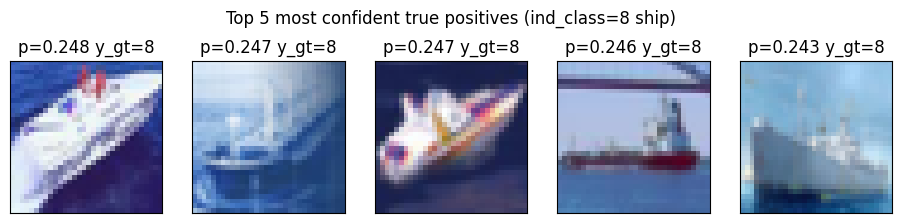

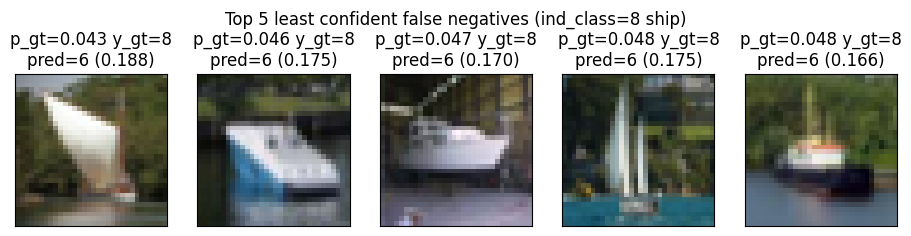

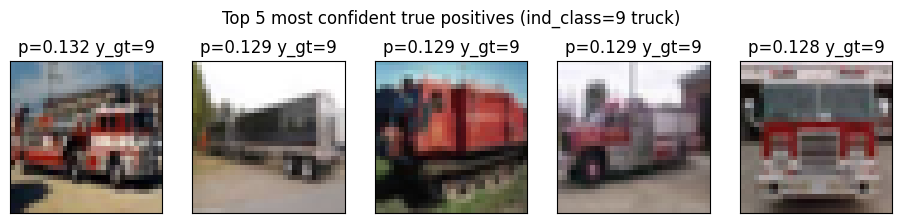

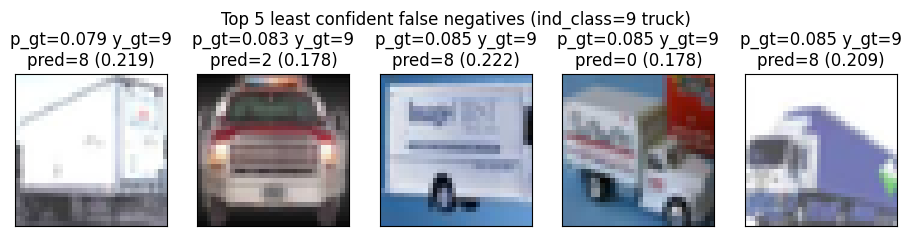

In [ ]:
# Visualize predictions
for ind_class, class_name in enumerate(test_data_cifar10.classes):
    visualize_predictions(
        pred_logits=pred_logits.numpy(),
        X=test_images.numpy(),
        num_chans_img=3,
        h_img=32,
        w_img=32,
        y=gt_labels.numpy(),
        ind_class_to_viz=ind_class,
        class_name_to_viz=class_name,
        top_k=5,
    )

Looking at these results, you can start making some interesting observations of the failure modes of the model.
An important aspect of model development is designing the good metrics to gain important insights into your model behavior.

For instance, total average classification accuracy is somewhat unsatisfying, as it's too coarse of a metric: it doesn't tell me if we're doing better on "dogs" vs "frogs".
Thus, we'd probably want to calculate per-class metrics: we may find that we're doing very well on "dogs" (an easy class), but poorly on frogs (a hard class).
Or, that we're frequently confusing "horse" for "dog"/"cat", or "bird" for "airplane".

Or, even more devilish details: perhaps we're doing well on images of "dogs" that are facing left, but poorly when they face right.
(Tip: this learning would encourage us to enable `RandomFlipHorizontal` image data augmentation to encourage the model to learn robustness against horizontal flips!)

Maybe we want to calculate [precision/recall curves](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html) to get insight into false-positives vs false-negatives.

Evaluation metrics is a (deceptively) complex, yet crucial topic!

# Saving/loading models

Once we have a model we're happy with, we typically will want to save the model snapshot to disk so that we can load it later:

In [59]:
# A Module's state_dict is a dictionary containing all of a model's state, which
# (among other things like buffers) contains the model's parameters.
print(model.state_dict())

OrderedDict({'linear_blocks.0.weight': tensor([[-2.7635e-03,  8.7099e-03, -4.1857e-05,  ...,  6.8577e-03,
          3.1696e-04, -1.0973e-02],
        [-4.4048e-03, -5.5120e-03,  1.7646e-02,  ..., -1.5572e-02,
         -7.6186e-03, -1.6359e-02],
        [ 4.4295e-03, -9.5806e-04,  1.5244e-02,  ..., -1.3547e-02,
          3.2799e-03, -3.7115e-03],
        ...,
        [ 1.3827e-02,  1.7602e-02, -1.0865e-02,  ...,  1.8387e-02,
         -1.2028e-03,  1.4252e-03],
        [ 9.1618e-04, -3.3528e-04, -4.0902e-03,  ...,  2.3877e-03,
          6.8305e-03, -1.3995e-03],
        [ 1.1355e-03,  2.0259e-03,  1.0154e-02,  ...,  4.4685e-03,
         -2.2208e-03, -5.8698e-03]]), 'linear_blocks.0.bias': tensor([ 0.0201, -0.0035, -0.0128,  0.0018,  0.0553,  0.0347, -0.0311, -0.0265]), 'linear_blocks.1.linear.weight': tensor([[ 0.2409,  0.2364, -0.2131,  0.0264, -0.3534, -0.0526,  0.1324,  0.2952],
        [-0.1534, -0.0254,  0.0953, -0.1372,  0.2258,  0.0312, -0.1013,  0.3341],
        [-0.2374, -0.3288

In [64]:
# Save model snapshot
outpath = "model_cifar10_lec15.pth"
torch.save(model.state_dict(), outpath)
print(f"Saved PyTorch Model State to {outpath}")

Saved PyTorch Model State to model_cifar10_lec15.pth


In [66]:
# Load model snapshot
# (check) load model, evaluate on test set again
model_from_disk = MyMLPV2(num_input_feats=3*32*32, num_classes=10, num_blocks=2)
model_from_disk.load_state_dict(torch.load(outpath, weights_only=True))
print(f"Loaded model from disk at: {outpath}")
test(test_dataloader_cifar10, model_from_disk, loss_fn)

Loaded model from disk at: model_cifar10_lec15.pth
Test Error: 
 Accuracy: 22.3%, Avg loss: 2.159224 

Total test time: 1.7036230564117432 secs (throughput=5869.843074947873 samples/sec)


# Conclusion

That's PyTorch in a nutshell!

Takeaways:
- Pytorch makes it easy to define novel model architectures using common deep learning building blocks
- Pytorch and Needle utilize many of the same abstractions!
    - Dataset, DataLoader, Module, Optimizer
